In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

file_path = 'run1_Adoption.txt'

with open(file_path, 'r') as f:
    lines = [x.strip() for x in f.readlines()]

#find the index of the line that contains "Run"
index = [i for i, line in enumerate(lines) if "Run" in line]
index.append(len(lines))
print(index)
#create tuple startindex + length
idx_tup = [(start, index[i+1] - start) for i, start in enumerate(index[:-1])]

#collect
series = []
for start, length in idx_tup:
    x = [int(xx.split(" ")[0]) for xx in lines[start+1:start+length]]
    y = [float(xx.split(" ")[-1]) for xx in lines[start+1:start+length]]
    series.append(pd.Series(data=y, index=x))


#compile to pandas dataframe
df = pd.DataFrame([],index = np.arange(0, 10000))
for i, s in enumerate(series):
    df[f'Run {i}'] = s

df.dropna(inplace=True)
df.to_csv('Formatted_Data.csv')

[0, 501, 1002, 1503, 2004, 2505, 3006, 3507, 4008, 4509, 5010]


### Analysis for Negative Reviews

[0.654817546998611,
 0.7151542913092636,
 0.7343217034793882,
 0.7286570731932903,
 0.7498313647258062,
 0.7731624336422189,
 0.8744360884270754,
 0.9301243994112516,
 0.9793670954706878,
 1.0]

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


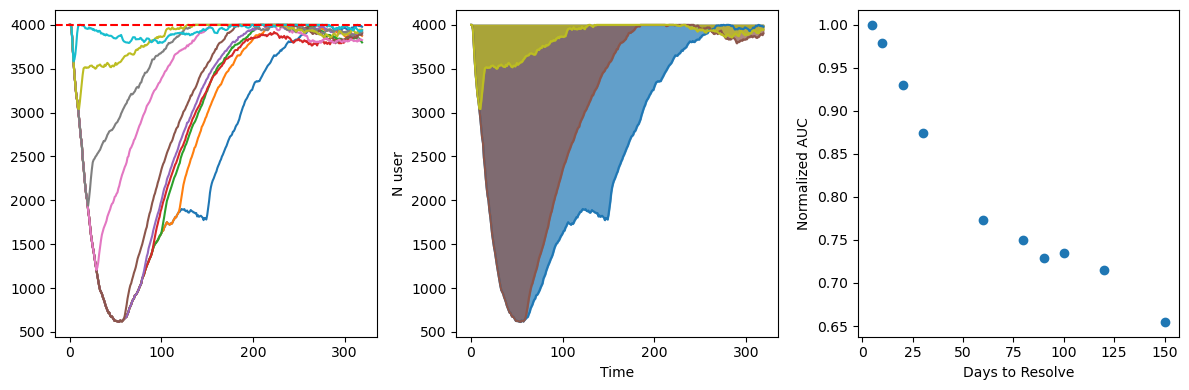

In [6]:
event = [150,
120,
100,
90,
80,
60,
30,
20,
10,
5]

def proc_crossing(arr, val):
    tmp = np.abs(np.array(arr) - val * 1.0)
    return np.argmin(tmp)


threshold = 4000
tmp = df.iloc[180:,:].reset_index(drop=True)
tmp = tmp.clip(upper=4000)
min = [proc_crossing(tmp.iloc[id:,][col], threshold) for id, col in zip(event, tmp.columns)]

#compute area under the curve
from scipy.integrate import trapezoid
auc = [trapezoid(tmp[col]) for id, col in zip(event, tmp.columns)]
display(list(auc/auc[-1]))


fig, ax = plt.subplots(1,3, figsize=(12,4))
tmp.plot(ax=ax[0], legend=False)
ax[0].axhline(y=threshold, color='r', linestyle='--')

colors = [line.get_color() for line in ax[0].lines[:-1]]
print(colors)
for select in [0,5,-2]:
    col = tmp.columns[select]
    color = colors[select]
    ax[1].plot(tmp[col], color=color)
    ax[1].fill_between(tmp.index, tmp[col], 4000,
                        alpha=0.7, color=color)

ax[2].plot(event,list(auc/auc[-1]), 
           marker='o',
           linestyle='',)

ax[1].set_ylabel('N user')
ax[1].set_xlabel('Time')


ax[2].set_ylabel('Normalized AUC')
ax[2].set_xlabel('Days to Resolve')
fig.tight_layout()

AUC represents the total cumulative engagement or total user time. For example, if there are 200 active users using the product for 2 hrs, the total cumulative engagement is 200 * 2 = 400 user-hours.

* The user-hours tend to drop drastically (-) about 75% relative to control at 60days to resolve a negative reviews. 
* Meanwhile when the issue is not resolved for more than 60 days, the user-hours further decrease to 0.65 at a slower pace.
* This engagement metric may be relevant to subscription-based models.